# EDA : Online Retail Dataset 
## Rumusan Masalah :
1. Apa 5 negara yang melakukan transaksi dengan nominal terbesar?
2. Kapan waktu terjadinya transaksi paling ramai?
3. Apa saja barang/produk yang paling banyak dibeli (TOP 10)?
4. Apa saja barang/produk yang paling bayan direfund (TOP 5)?

## Dataset
Online Retail Dataset (Kaggle, by Ulrik Thyge Pedersen) — transaksi UK-based online retail.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r'D:\Michael Road To Data Analyst\Dataset\online_retail.csv')
df.info()
df.shape
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
# Memisahkan data yang dibatalkan
# Dilakukan lagi setelah pembersihan agar df_successed mengikuti data terbaru
df_cancelled = df[df['InvoiceNo'].str.startswith('C')]
df_successed = df[df['InvoiceNo'].str.startswith('C') == False]

# Mengecek apakah ada data yang kosong
df.isnull().sum()

# Mengisi data yang kosong
df['Description'] = df['Description'].fillna('No Description')

# Menghapus baris yang CustomerID-nya kosong agar tidak terjadi kesalahan data dalam groupby
df['CustomerID'] = df['CustomerID'].fillna(0)
df = df[df['CustomerID'] != 0]

# Ubah tipe data biar sesuai
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)

df_successed.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


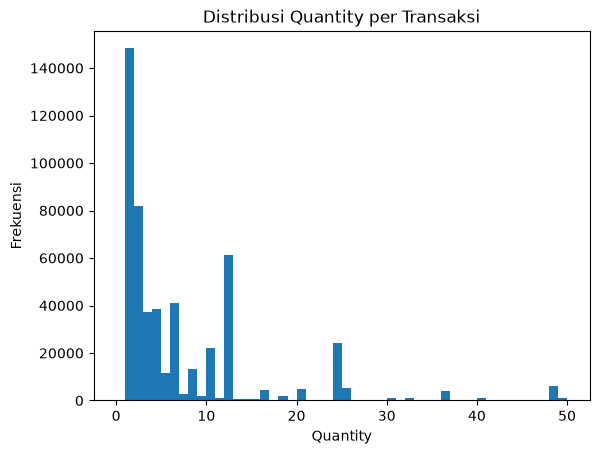

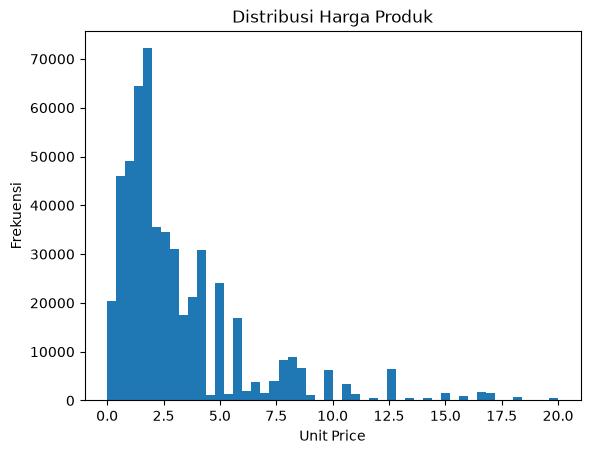

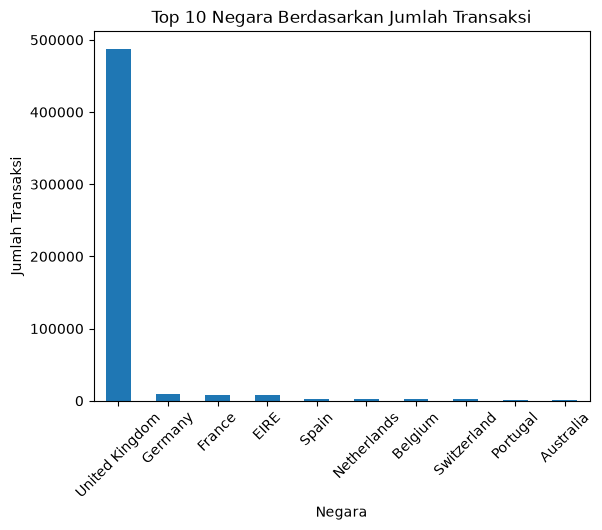

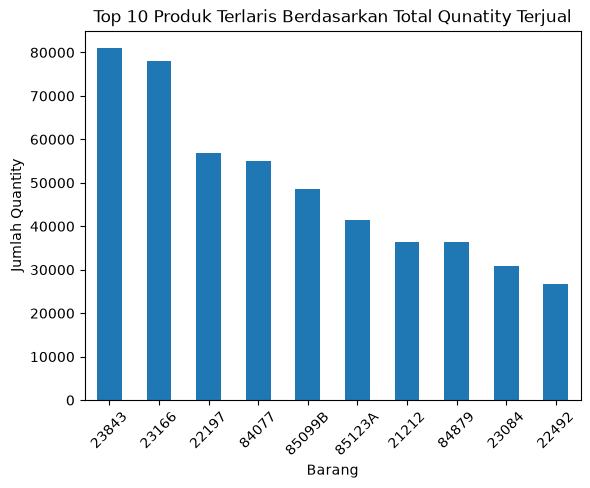

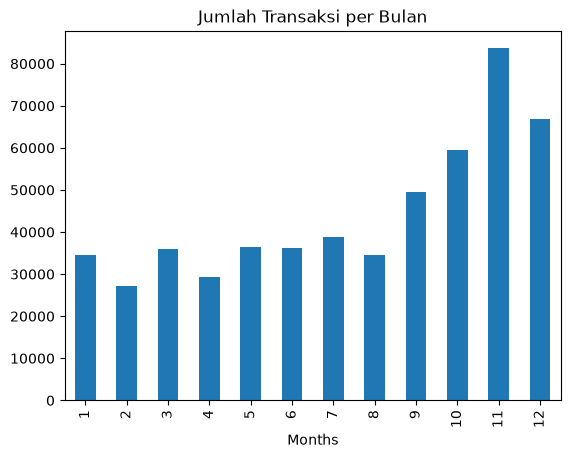

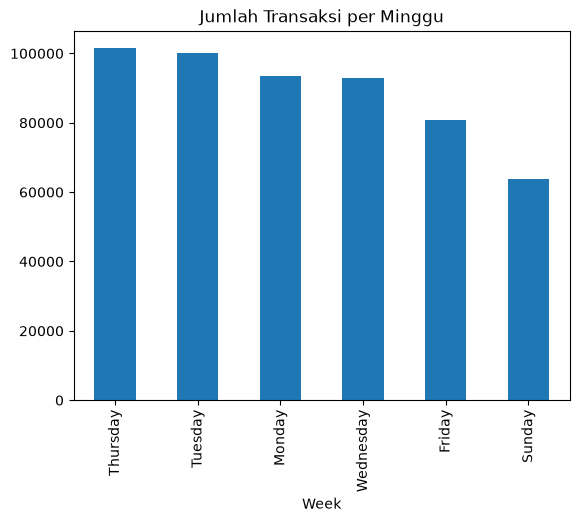

In [7]:
#Distribusi Quantity per Transaksi
plt.hist(df_successed['Quantity'], bins=50, range=(0,50))
plt.title('Distribusi Quantity per Transaksi')
plt.xlabel('Quantity')
plt.ylabel('Frekuensi')
plt.show()

#Distribusi Unit Price
plt.hist(df_successed['UnitPrice'], bins=50, range=(0,20))
plt.title('Distribusi Harga Produk')
plt.xlabel('Unit Price')
plt.ylabel('Frekuensi')
plt.show()

#Top 10 Negara berdasarkan Jumlah Transaksi
top_10 = df_successed['Country'].value_counts().head(10)
top_10.plot(kind='bar')
plt.xticks(rotation=45)
plt.title('Top 10 Negara Berdasarkan Jumlah Transaksi')
plt.xlabel('Negara')
plt.ylabel('Jumlah Transaksi')
plt.show()

#Top 10 produk terlaris (berdasarkan total Quantity terjual)
top_10_produk = df_successed.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(10)
top_10_produk.plot(kind='bar')
plt.xticks(rotation=45)
plt.title('Top 10 Produk Terlaris Berdasarkan Total Qunatity Terjual')
plt.xlabel('Barang')
plt.ylabel('Jumlah Quantity')
plt.show()

#Waktu Transaksi Paling Ramai
df_successed['InvoiceDate'] = pd.to_datetime(df_successed['InvoiceDate'])
df_successed['Months'] = df_successed['InvoiceDate'].dt.month
df_successed['Months'].value_counts().sort_index().plot(kind='bar')
plt.title('Jumlah Transaksi per Bulan')
plt.show()

df_successed['Week'] = df_successed['InvoiceDate'].dt.day_name()
df_successed['Week'].value_counts().plot(kind='bar')
plt.title('Jumlah Transaksi per Minggu')
plt.show()

In [8]:
df_successed.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Months,Week
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,Wednesday


# Apa 5 negara yang melakukan transaksi dengan nominal terbesar?

Text(0, 0.5, 'Unit Price')

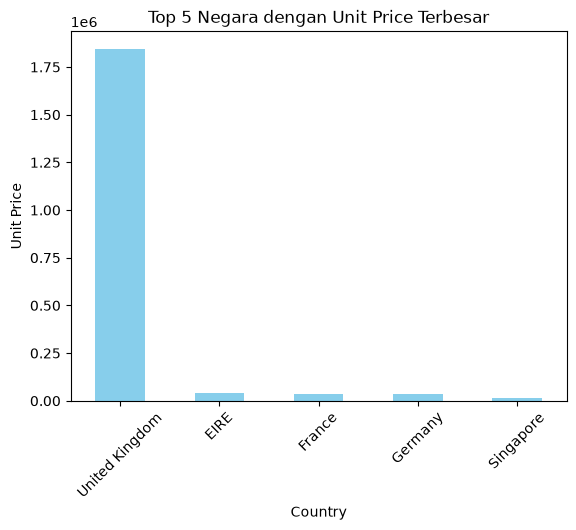

In [ ]:
df_successed.groupby('Country')['UnitPrice'].sum().sort_values(ascending=False).head(5).plot(kind = 'bar', color = 'skyblue')
plt.xticks(rotation = 45)
plt.title('Top 5 Negara dengan Unit Price Terbesar')
plt.ylabel('Unit Price')

# Kapan waktu terjadinya transaksi paling ramai?

Text(0.5, 1.0, 'Tren Transaksi per Bulan')

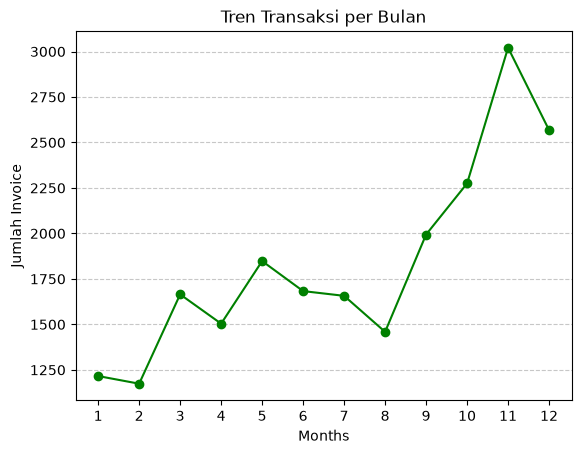

In [ ]:
df_successed['InvoiceDate'] = pd.to_datetime(df_successed['InvoiceDate'])
df_successed['Months'] = df_successed['InvoiceDate'].dt.month
tren_bulanan = df_successed.groupby('Months')['InvoiceNo'].nunique()
tren_bulanan.plot(kind = 'line', marker='o',color='green')
plt.xticks(range(1,13))
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.ylabel('Jumlah Invoice')
plt.title('Tren Transaksi per Bulan')

# Apa saja barang/produk yang paling banyak dibeli (TOP 10)?

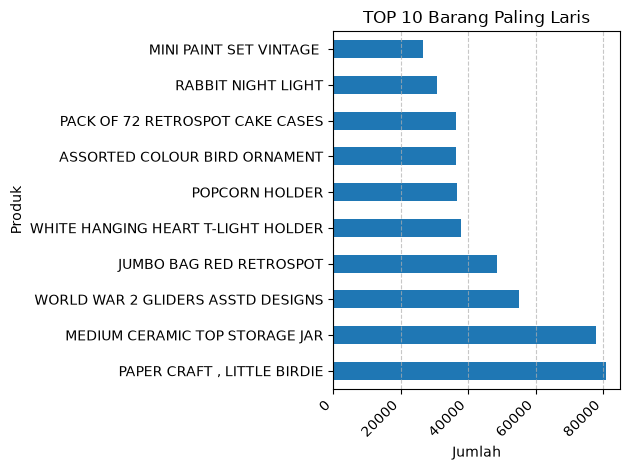

In [ ]:
top_10_produk = df_successed.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_10_produk.plot(kind='barh')
plt.xticks(rotation = 45, ha='right')
plt.ylabel('Produk')
plt.xlabel('Jumlah')
plt.title('TOP 10 Barang Paling Laris')
plt.grid(True, axis = 'x', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

# Apa saja barang/produk yang paling bayak direfund (TOP 5)?

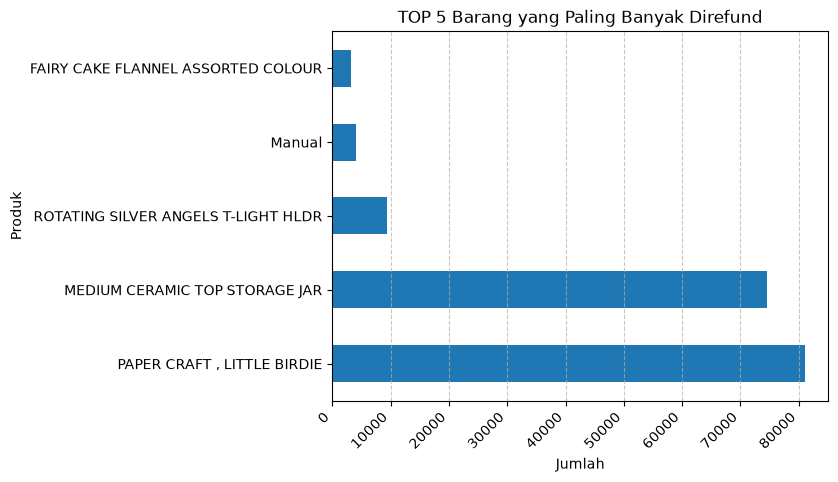

In [ ]:
top_5_refund = df_cancelled.groupby('Description')['Quantity'].sum().abs().sort_values(ascending=False).head()
top_5_refund.plot(kind = 'barh')
plt.xticks(rotation = 45, ha = 'right')
plt.ylabel('Produk')
plt.xlabel('Jumlah')
plt.title("TOP 5 Barang yang Paling Banyak Direfund")
plt.grid(True, linestyle = '--', axis = 'x', alpha = 0.7)
plt.show()


## Menjawab Rumusan Masalah :
1. Apa 5 negara yang melakukan transaksi dengan nominal terbesar?

Top 5 negara yang melakukan trasnsaksi dengan nominal terbesar : 
- United Kingdom
- EIRE
- France
- Germany
- Singapore

2. Kapan waktu terjadinya transaksi paling ramai?

Transaksi paling ramai mencapai puncaknya pada bulan November.

3. Apa saja barang/produk yang paling banyak dibeli (TOP 10)?

TOP 10 Barang/Produk paling banyak dibeli :
- Paper Craft, Little Birdie
-  Medium Ceramic TOP Storage Jar
-  World War 2 Gliders ASSTD Designs
-  Jumbo Bag Red Retrospot
- White Hanging Heart T-Light Golder
- Popcorn Holder
- Assorted Colour Bird Ornament
- Pack of 72 Retrospot Cake Cases
- Rabbit Night Light
- Mini Paint Set vintage

4. Apa saja barang/produk yang paling bayak direfund (TOP 5)?

TOP 5 Barang/Produk paling banyak direfund : 
- Paper Craft, Little Birdie
- Medium Ceramic Top Storage Jar
- Rotating Silver Angels T-Light Jar
- Manual
- Fairy Cake Flannel Assorted Colour

## Kesimpulan :
Berdasarkan jawaban-jawaban dari pertanyaan diatas, maka dapat saya simpulkan bahwa penjualan perusahaan paling ramai berada pada bulan November dan paling sepi pada bulan Februari dengan United Kingdom sebagai negara yang melakukan pembelian paling banyak. Akan tetapi, ditemukan keanehan pada barang Paper Craft, Little Birdie dan Medium Ceramic TOP Storage Jar. Kedua barang tersebut berada pada TOP 2 barang terlaris sekaligus barang paling banyak direfund. Sehingga diperlukan analisis lebih mendalam mengapa hal ini bisa terjadi.